In [1]:
import os
import joblib
import opensmile
import numpy as np

# -------------------------
# Load the saved model
# -------------------------
model_path = 'models/random_forest_opensmile_model.pkl'
clf = joblib.load(model_path)
print(f"✅ Model loaded from: {model_path}")

# -------------------------
# Initialize OpenSMILE feature extractor
# -------------------------
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.ComParE_2016,
    feature_level=opensmile.FeatureLevel.Functionals,
)

# -------------------------
# Function to extract features from a single file
# -------------------------
def extract_opensmile_features_from_file(file_path):
    feat = smile.process_file(file_path)
    return feat.values.flatten().reshape(1, -1)  # Reshape for sklearn

# -------------------------
# Predict on a single file
# -------------------------
def predict_audio(file_path):
    features = extract_opensmile_features_from_file(file_path)
    prediction = clf.predict(features)
    label = "real" if prediction[0] == 0 else "fake"
    print(f"🎧 File: {os.path.basename(file_path)} --> Prediction: {label}")

# -------------------------
# Test on a folder of new audio files (optional)
# -------------------------
def predict_from_folder(folder_path):
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.wav'):
            file_path = os.path.join(folder_path, file_name)
            predict_audio(file_path)

# -------------------------
# USAGE
# -------------------------

# Predict on a single new audio file
# test_file = '/path/to/your/new_audio.wav'
# predict_audio(test_file)

# Or predict on a folder of .wav files
test_folder = '/Users/aviralchauhan/College/Sem8/hcai/final_project/deepfake_detection/test_data'
predict_from_folder(test_folder)

✅ Model loaded from: models/random_forest_opensmile_model.pkl
🎧 File: real.wav --> Prediction: real
🎧 File: aviral.wav --> Prediction: real
🎧 File: mahansh_real.wav --> Prediction: real
🎧 File: deepfake.wav --> Prediction: real


In [4]:
import os
import torch
import torchaudio
import numpy as np
import joblib
from tqdm import tqdm
from transformers import Wav2Vec2Processor, Wav2Vec2Model

# -------------------------
# Load saved model
# -------------------------
model_path = "models/wav2vec_svm_model.pkl"
clf = joblib.load(model_path)
print(f"✅ Model loaded from: {model_path}")

# -------------------------
# Load Wav2Vec2 processor and model
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Usage: {device}')
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(device)

# -------------------------
# Feature extraction for new audio
# -------------------------
def extract_features(file_path):
    audio, sr = torchaudio.load(file_path)

    # Resample if needed
    if sr != 16000:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=16000)
        audio = resampler(audio)

    inputs = processor(audio.squeeze(), sampling_rate=16000, return_tensors="pt", padding=True)
    with torch.no_grad():
        outputs = model(inputs.input_values.to(device))
    embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
    return embeddings

# -------------------------
# Predict on a single audio file
# -------------------------
def predict_audio(file_path):
    features = extract_features(file_path)
    prediction = clf.predict(features)
    label = "real" if prediction[0] == 0 else "fake"
    print(f"🎧 {os.path.basename(file_path)} --> Prediction: {label}")

# -------------------------
# Predict on a folder of audio files (optional)
# -------------------------
def predict_from_folder(folder_path):
    files = [f for f in os.listdir(folder_path) if f.endswith(".wav")]
    for file in tqdm(files, desc="Predicting", unit="file"):
        file_path = os.path.join(folder_path, file)
        predict_audio(file_path)

# -------------------------
# USAGE
# -------------------------

# Test on a single new file
# predict_audio("/path/to/new_audio.wav")

# Or test on a folder of files
predict_from_folder("/Users/aviralchauhan/College/Sem8/hcai/final_project/deepfake_detection/test_data")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.2.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✅ Model loaded from: models/wav2vec_svm_model.pkl
Usage: cpu


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Predicting:  50%|█████     | 2/4 [00:00<00:00,  4.08file/s]

🎧 real.wav --> Prediction: fake
🎧 aviral.wav --> Prediction: fake


Predicting: 100%|██████████| 4/4 [00:01<00:00,  2.76file/s]

🎧 mahansh_real.wav --> Prediction: fake
🎧 deepfake.wav --> Prediction: fake


In [5]:
import os
import torch
import torchaudio
import numpy as np
import joblib
from tqdm import tqdm
from transformers import Wav2Vec2FeatureExtractor, WavLMModel

# Load the trained Logistic Regression model
model_path = "models/logistic_model_wavlm.pkl"
clf = joblib.load(model_path)
print(f"✅ Loaded model from {model_path}")

# Set up WavLM processor and model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Usage: {device}')
processor = Wav2Vec2FeatureExtractor.from_pretrained("microsoft/wavlm-base")
model = WavLMModel.from_pretrained("microsoft/wavlm-base").to(device)

# Extract WavLM features for a single audio file
def extract_features(file_path):
    audio, sr = torchaudio.load(file_path)
    
    # Resample if not 16kHz
    if sr != 16000:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=16000)
        audio = resampler(audio)
    
    inputs = processor(audio.squeeze(), sampling_rate=16000, return_tensors="pt", padding=True)
    with torch.no_grad():
        outputs = model(inputs.input_values.to(device))
    embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
    return embeddings

# Predict for a single file
def predict_audio(file_path):
    features = extract_features(file_path)
    prediction = clf.predict(features)
    label = "real" if prediction[0] == 0 else "fake"
    print(f"🎧 {os.path.basename(file_path)} --> Prediction: {label}")

# Predict for a folder of files (optional)
def predict_from_folder(folder_path):
    files = [f for f in os.listdir(folder_path) if f.endswith(".wav")]
    for file in tqdm(files, desc="Predicting", unit="file"):
        file_path = os.path.join(folder_path, file)
        predict_audio(file_path)

# Example usage:
# Predict a single file
# predict_audio("/path/to/new_audio.wav")

# Or predict all files in a folder
predict_from_folder("/Users/aviralchauhan/College/Sem8/hcai/final_project/deepfake_detection/test_data")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.2.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✅ Loaded model from models/logistic_model_wavlm.pkl
Usage: cpu


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.24k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Predicting:  50%|█████     | 2/4 [00:00<00:00,  3.03file/s]

🎧 real.wav --> Prediction: fake
🎧 aviral.wav --> Prediction: fake


Predicting: 100%|██████████| 4/4 [00:01<00:00,  2.91file/s]

🎧 mahansh_real.wav --> Prediction: fake
🎧 deepfake.wav --> Prediction: fake


model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 963ms/step
Prediction: [[0.50763434]]
Prediction: Fake


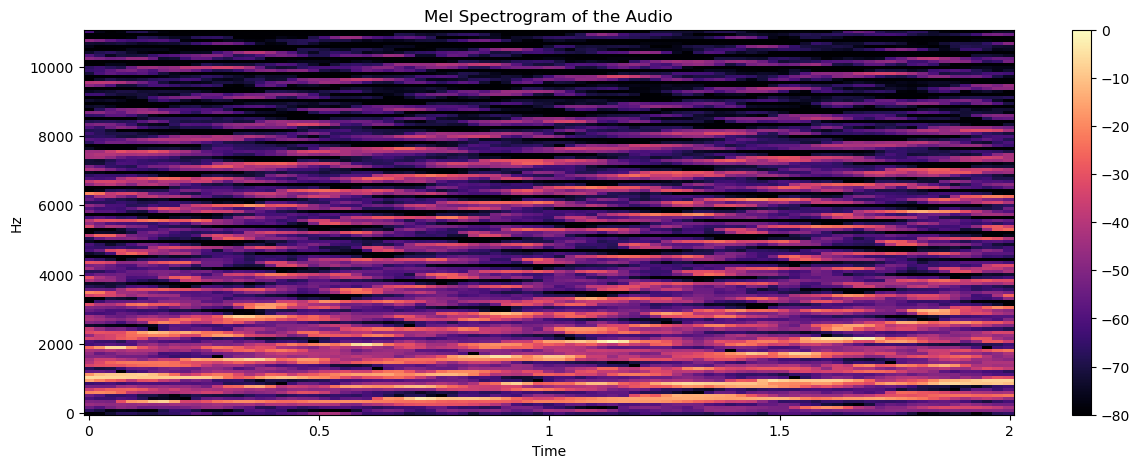

In [9]:
import librosa
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import librosa.display

# Step 1: Load the saved model
model = tf.keras.models.load_model('/Users/aviralchauhan/College/Sem8/hcai/final_project/deepfake_detection/models/Deepfake Audio Detector Model.h5')

# Step 2: Preprocess the audio file and convert it into a Mel spectrogram
def create_mel_spectrogram(file_path):
    # Load the audio file
    audio_data, sample_rate = librosa.load(file_path)
    
    # Convert audio to mel spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sample_rate)
    
    # Convert the Mel spectrogram from amplitude to decibels
    mel_decibel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
    
    return mel_decibel_spectrogram

# Step 3: Define the function to process and reshape the spectrogram for prediction
def preprocess_audio_for_prediction(file_path):
    # Generate the Mel spectrogram
    mel_spectrogram = create_mel_spectrogram(file_path)
    
    # Resize the spectrogram to match the input shape expected by the model (128x87)
    mel_spectrogram_resized = np.resize(mel_spectrogram, (128, 87))
    
    # Add an extra dimension to represent the "channel" (grayscale)
    mel_spectrogram_resized = np.expand_dims(mel_spectrogram_resized, axis=-1)
    
    # Expand dimensions to match the batch size (we're testing on one sample)
    mel_spectrogram_resized = np.expand_dims(mel_spectrogram_resized, axis=0)
    
    return mel_spectrogram_resized

# Step 4: Load an audio file for testing (replace this with your file path)
audio_file = "/Users/aviralchauhan/College/Sem8/hcai/final_project/deepfake_detection/test_data/real.wav"  # Replace this with your actual file path

# Step 5: Preprocess the audio file for prediction
mel_spectrogram_resized = preprocess_audio_for_prediction(audio_file)

# Step 6: Make a prediction using the trained model
prediction = model.predict(mel_spectrogram_resized)
print(f'Prediction: {prediction}')

# Step 7: Display the prediction
if prediction[0] > 0.5:
    print("Prediction: Fake")
else:
    print("Prediction: Real")

# Step 8: Optionally, display the Mel spectrogram for visualization
plt.figure(figsize=(15, 5))
librosa.display.specshow(mel_spectrogram_resized[0, :, :, 0], x_axis='time', y_axis='hz')
plt.colorbar()
plt.title('Mel Spectrogram of the Audio')
plt.show()